In [8]:
"""
Final cleaning pass on AllRoles_clean.csv, producing the dataset that's
actually ready to send to the NIOCCS API.

Output: one row per unique historical opportunity, restricted to the 4
core Career Launch/Spring Forward hubs, where both the role name and role
description have real (non-placeholder, non-blank) content. Short/generic
content is fine and is NOT filtered out here - only rows with nothing
usable are dropped.

FILTERS APPLIED (in order, each one printed so nothing disappears quietly)
---------------------------------------------------------------------------
1. Hub Normalized must be one of the 4 core hubs:
   Healthcare, STEM and Green, Community and Social Services,
   Marketing and Communications.
   (Government and Public Service is dropped here - it only ever existed
   in the 2022 cohort and isn't one of the 4 hubs going forward. Cultural
   Corps/I2E rows were already out of scope per the diagnostic pass.)
2. Opportunity Name (role name) must be non-blank.
3. Opportunity Description (role description) must be non-blank.
4. Opportunity Name must not be an unfilled placeholder/template stub
   (e.g. "Enter Your Job Title Here") - these have text, but it isn't
   real content, so they don't satisfy "at least something."
5. Duplicate Opportunity Ids are dropped, keeping the first occurrence
   (there weren't any in the raw file, but this makes the "one row per
   unique historical opportunity" guarantee explicit rather than assumed).

Everything that survives keeps its own text as-is, however short or
generic - per direction, that's fine.
"""

import pandas as pd
import re

IN_PATH = "../../data/AllRoles_clean.csv"
OUT_PATH = "../../data/AllRoles_nioccs_ready.csv"

CORE_HUBS = {
    "Healthcare",
    "STEM and Green",
    "Community and Social Services",
    "Marketing and Communications",
}

PLACEHOLDER_TITLE_RE = re.compile(
    r"enter your job title here|insert title of position here|"
    r"organization name.*job position|insert name of org",
    re.I,
)


def is_placeholder_title(title):
    if pd.isna(title):
        return False
    return bool(PLACEHOLDER_TITLE_RE.search(str(title)))


def main():
    df = pd.read_csv(IN_PATH, encoding="utf-8-sig", low_memory=False)
    n_start = len(df)
    print(f"Starting rows: {n_start}")

    # 1. Restrict to the 4 core hubs
    df = df[df["Hub Normalized"].isin(CORE_HUBS)]
    print(f"After restricting to the 4 core hubs: {len(df)} (-{n_start - len(df)})")
    n = len(df)

    # 2 & 3. Both title and description must be non-blank
    df = df[df["Opportunity Name"].notna() & (df["Opportunity Name"].str.strip() != "")]
    df = df[df["Opportunity Description"].notna() & (df["Opportunity Description"].str.strip() != "")]
    print(f"After requiring non-blank title AND description: {len(df)} (-{n - len(df)})")
    n = len(df)

    # 4. Drop unfilled placeholder/template postings
    df = df[~df["Opportunity Name"].apply(is_placeholder_title)]
    print(f"After dropping placeholder/template titles: {len(df)} (-{n - len(df)})")
    n = len(df)

    # 5. Guarantee uniqueness on Opportunity Id
    df = df.drop_duplicates(subset=["Opportunity Id"], keep="first")
    print(f"After deduplicating on Opportunity Id: {len(df)} (-{n - len(df)})")

    print(f"\nFinal dataset: {len(df)} rows ({len(df) / n_start * 100:.1f}% of starting rows)")
    print("\nRows per hub in final dataset:")
    print(df["Hub Normalized"].value_counts().to_string())
    print("\nRows per cohort year in final dataset:")
    print(df["Cohort Year"].value_counts().sort_index().to_string())

    # Keep a clean, descriptively-named set of columns for the API step.
    # "Hub Normalized" is what will be passed as i= for every row, including
    # STEM and Green - no special-casing there per direction.
    out = df[[
        "Opportunity Id", "Opportunity Name", "Opportunity Description",
        "Hub Normalized", "Cohort Year", "Program Family", "Agency Name",
    ]].rename(columns={
        "Opportunity Id": "Opportunity Identifier",
        "Opportunity Name": "Role Name",
        "Opportunity Description": "Role Description",
        "Hub Normalized": "Program Hub Category",
    })

    out.to_csv(OUT_PATH, index=False)
    print(f"\nWrote {OUT_PATH}")

    return out


if __name__ == "__main__":
    main()

Starting rows: 9297
After restricting to the 4 core hubs: 7194 (-2103)
After requiring non-blank title AND description: 7193 (-1)
After dropping placeholder/template titles: 7125 (-68)
After deduplicating on Opportunity Id: 7125 (-0)

Final dataset: 7125 rows (76.6% of starting rows)

Rows per hub in final dataset:
Hub Normalized
Community and Social Services    2398
Marketing and Communications     1963
STEM and Green                   1445
Healthcare                       1319

Rows per cohort year in final dataset:
Cohort Year
2022.0     603
2023.0    1416
2024.0    1580
2025.0    1673
2026.0    1853

Wrote ../../data/AllRoles_nioccs_ready.csv


In [2]:
# --- NIOCCS NAICS/SOC auto-classification - call the API on AllRoles_nioccs_ready.csv ---
#
# NOTE: I can't hit wwwn.cdc.gov from my own sandbox to test this end-to-end,
# so treat the first TEST_MODE run below as the real verification step -
# check the raw JSON it prints before trusting the parsed columns or moving
# to the full batch. Field names in `parse_nioccs_response` are my best read
# of the spec you gave me; adjust them once you see a real response.

import pandas as pd
import requests
import time
import json
import os

IN_PATH = "../../data/AllRoles_nioccs_ready.csv"
CHECKPOINT_PATH = "../../data/AllRoles_nioccs_coded.csv"

NIOCCS_BASE_URL = "https://wwwn.cdc.gov/nioccs/IOCode"
REQUEST_PARAMS_STATIC = {"c": 2, "v": 18, "u": 1, "n": 1}

import re

# Cap on the occupation text sent to the API. Duties-section extraction
# (below) already drops most boilerplate, so this is now mostly a safety
# ceiling rather than doing the real trimming work.
MAX_DESCRIPTION_CHARS = 1200

# Postings routinely open with a preamble paragraph before the actual
# duties (e.g. "Work as an extension of the Digital Marketing Team...")
# which can be pure boilerplate reused across *different* roles at the
# same agency - regardless of what the specific role actually is. Sending
# that preamble to the API can outweigh the real duties in the occupation
# match. So: pull out the DUTIES & RESPONSIBILITIES section specifically,
# and stop before the next known section header, rather than truncating
# blindly from the top of the description.
DUTIES_HEADER_RE = re.compile(r"duties\s*&?\s*responsibilities\s*:?", re.I)
NEXT_SECTION_HEADER_RE = re.compile(
    r"(intern will learn|qualifications|work schedule|location\s*:)", re.I
)


def extract_duties_text(description: str) -> str:
    """
    Returns the DUTIES & RESPONSIBILITIES section if a clear header is
    found, stopping at the next known section header. Falls back to the
    full description (truncated later) if no DUTIES header is present -
    some postings don't use this template.
    """
    if pd.isna(description):
        return ""
    text = str(description)
    match = DUTIES_HEADER_RE.search(text)
    if not match:
        return text  # no DUTIES header found - use the whole description

    after_header = text[match.end():]
    next_header = NEXT_SECTION_HEADER_RE.search(after_header)
    duties_text = after_header[: next_header.start()] if next_header else after_header
    duties_text = duties_text.strip()
    return duties_text if duties_text else text  # guard against an empty extract

# TEST_MODE = True runs on just the first TEST_SAMPLE_SIZE rows and prints
# the raw response for each, so you can sanity-check field names before
# committing to the full batch. Flip to False (and re-run the cell) once
# you've confirmed the parsing looks right.
TEST_MODE = False
TEST_SAMPLE_SIZE = 10

# Be a polite, unauthenticated guest on a free public CDC endpoint.
SECONDS_BETWEEN_REQUESTS = 0.5
MAX_RETRIES_PER_ROW = 3

# Sentinel codes per the NIOCCS spec - these mean "insufficient information
# to code," not a real match.
NAICS_INSUFFICIENT_INFO_CODE = "009990"
SOC_INSUFFICIENT_INFO_CODE = "00-9900"


def build_occupation_text(role_name: str, role_description: str) -> str:
    role_name = "" if pd.isna(role_name) else str(role_name).strip()
    duties_text = extract_duties_text(role_description)
    combined = f"{role_name}. {duties_text}"
    return combined[:MAX_DESCRIPTION_CHARS]


def call_nioccs(industry_text: str, occupation_text: str) -> dict:
    """
    Calls the NIOCCS API for a single row. Returns a dict with:
      - 'raw_response': the parsed JSON (or None if the call failed)
      - 'http_status': status code (or None)
      - 'error': error message if something went wrong, else None
    Retries transient failures a few times before giving up on the row.
    """
    params = {
        **REQUEST_PARAMS_STATIC,
        "i": industry_text,
        "o": occupation_text,
    }

    last_error = None
    for attempt in range(1, MAX_RETRIES_PER_ROW + 1):
        try:
            resp = requests.get(NIOCCS_BASE_URL, params=params, timeout=20)
            if resp.status_code == 200:
                try:
                    return {"raw_response": resp.json(), "http_status": 200, "error": None}
                except json.JSONDecodeError:
                    last_error = f"Non-JSON response (status 200): {resp.text[:200]}"
            else:
                last_error = f"HTTP {resp.status_code}: {resp.text[:200]}"
        except requests.exceptions.RequestException as e:
            last_error = f"Request exception: {e}"

        if attempt < MAX_RETRIES_PER_ROW:
            time.sleep(1.5 * attempt)  # simple backoff before retrying

    return {"raw_response": None, "http_status": None, "error": last_error}


def parse_nioccs_response(raw) -> dict:
    """
    Extracts NAICS/SOC codes from the real NIOCCS response shape (confirmed
    from a test run):

        {
          "Industry": [{"NAICSCode": ..., "NAICSTitle": ..., "NAICSProbability": ...}],
          "Occupation": [{"SOCCode": ..., "SOCTitle": ..., "SOCProbability": ...}],
          "UnexpectedCodeCombination": "Y" or "N"
        }

    Takes the first entry in each list (n=1 in the request params means we
    only asked for the top match anyway).
    """
    empty = {
        "naics_code": None, "naics_title": None, "naics_probability": None,
        "soc_code": None, "soc_title": None, "soc_probability": None,
        "naics_insufficient_info": None, "soc_insufficient_info": None,
        "implausible_pairing_flag": None,
    }
    if not isinstance(raw, dict):
        return empty

    industry = raw.get("Industry") or []
    occupation = raw.get("Occupation") or []
    industry_rec = industry[0] if industry else {}
    occupation_rec = occupation[0] if occupation else {}

    naics_code = industry_rec.get("NAICSCode")
    soc_code = occupation_rec.get("SOCCode")

    return {
        "naics_code": naics_code,
        "naics_title": industry_rec.get("NAICSTitle"),
        "naics_probability": industry_rec.get("NAICSProbability"),
        "soc_code": soc_code,
        "soc_title": occupation_rec.get("SOCTitle"),
        "soc_probability": occupation_rec.get("SOCProbability"),
        "naics_insufficient_info": (naics_code == NAICS_INSUFFICIENT_INFO_CODE) if naics_code else None,
        "soc_insufficient_info": (soc_code == SOC_INSUFFICIENT_INFO_CODE) if soc_code else None,
        "implausible_pairing_flag": raw.get("UnexpectedCodeCombination") == "Y",
    }


def load_already_coded():
    """Resume support: skip rows we've already successfully coded."""
    if os.path.exists(CHECKPOINT_PATH):
        done = pd.read_csv(CHECKPOINT_PATH)
        return done, set(done["Opportunity Identifier"])
    return pd.DataFrame(), set()


def run():
    df = pd.read_csv(IN_PATH, encoding="utf-8-sig")

    if TEST_MODE:
        df = df.head(TEST_SAMPLE_SIZE)
        print(f"TEST MODE: running on {len(df)} rows only. Set TEST_MODE = False for the full batch.\n")

    done_df, done_ids = load_already_coded()
    if not TEST_MODE and done_ids:
        print(f"Resuming: {len(done_ids)} rows already coded in a previous run, skipping those.")
        df = df[~df["Opportunity Identifier"].isin(done_ids)]

    results = []
    total = len(df)
    for i, (_, row) in enumerate(df.iterrows(), start=1):
        opportunity_id = row["Opportunity Identifier"]
        role_name = row["Role Name"]
        role_description = row["Role Description"]
        industry_text = row["Program Hub Category"]  # STEM and Green included, no special-casing

        occupation_text = build_occupation_text(role_name, role_description)
        api_result = call_nioccs(industry_text, occupation_text)
        parsed = parse_nioccs_response(api_result["raw_response"])

        result_row = {
            "Opportunity Identifier": opportunity_id,
            "Role Name": role_name,
            "Program Hub Category": industry_text,
            "NAICS Code": parsed["naics_code"],
            "NAICS Title": parsed["naics_title"],
            "NAICS Match Probability": parsed["naics_probability"],
            "SOC Code": parsed["soc_code"],
            "SOC Title": parsed["soc_title"],
            "SOC Match Probability": parsed["soc_probability"],
            "NAICS Flagged As Insufficient Information": parsed["naics_insufficient_info"],
            "SOC Flagged As Insufficient Information": parsed["soc_insufficient_info"],
            "Flagged As Implausible NAICS/SOC Pairing": parsed["implausible_pairing_flag"],
            "API Call Error": api_result["error"],
        }
        results.append(result_row)

        if TEST_MODE:
            print(f"--- Row {i}/{total}: {role_name!r} ---")
            print("Raw response:", json.dumps(api_result["raw_response"], indent=2)[:1000])
            print("Parsed:", {k: v for k, v in result_row.items() if k not in ("Opportunity Identifier", "Role Name")})
            print()
        elif i % 25 == 0:
            print(f"...{i}/{total} rows called")

        time.sleep(SECONDS_BETWEEN_REQUESTS)

        # Checkpoint every 100 rows in full-batch mode, so a crash mid-run
        # doesn't cost you the whole batch.
        if not TEST_MODE and i % 100 == 0:
            combined = pd.concat([done_df, pd.DataFrame(results)], ignore_index=True)
            combined.to_csv(CHECKPOINT_PATH, index=False)
            print(f"Checkpoint saved: {len(combined)} rows coded so far.")

    results_df = pd.DataFrame(results)

    if not TEST_MODE:
        combined = pd.concat([done_df, results_df], ignore_index=True)
        combined.to_csv(CHECKPOINT_PATH, index=False)
        print(f"\nDone. {len(combined)} total rows coded, written to {CHECKPOINT_PATH}")
        n_errors = combined["API Call Error"].notna().sum()
        if n_errors:
            print(f"{n_errors} rows had a call error and should be re-run separately - "
                  f"they were still saved to the checkpoint file with the error message.")
    else:
        print(f"\nTest run complete on {len(results_df)} rows. Nothing written to disk yet - "
              f"review the raw responses above, fix parse_nioccs_response if the keys don't "
              f"match, then set TEST_MODE = False and re-run this cell for the full batch.")

    return results_df


results_df = run()
results_df

...25/7125 rows called
...50/7125 rows called
...75/7125 rows called
...100/7125 rows called
Checkpoint saved: 100 rows coded so far.
...125/7125 rows called
...150/7125 rows called
...175/7125 rows called
...200/7125 rows called
Checkpoint saved: 200 rows coded so far.
...225/7125 rows called
...250/7125 rows called
...275/7125 rows called
...300/7125 rows called
Checkpoint saved: 300 rows coded so far.
...325/7125 rows called
...350/7125 rows called
...375/7125 rows called
...400/7125 rows called
Checkpoint saved: 400 rows coded so far.
...425/7125 rows called
...450/7125 rows called
...475/7125 rows called
...500/7125 rows called
Checkpoint saved: 500 rows coded so far.
...525/7125 rows called
...550/7125 rows called
...575/7125 rows called
...600/7125 rows called
Checkpoint saved: 600 rows coded so far.
...625/7125 rows called
...650/7125 rows called
...675/7125 rows called
...700/7125 rows called
Checkpoint saved: 700 rows coded so far.
...725/7125 rows called
...750/7125 rows cal

,Opportunity Identifier,Role Name,Program Hub Category,NAICS Code,NAICS Title,NAICS Match Probability,SOC Code,SOC Title,SOC Match Probability,NAICS Flagged As Insufficient Information,SOC Flagged As Insufficient Information,Flagged As Implausible NAICS/SOC Pairing,API Call Error
0,395bf964-a1f1-455f-9e41-08dd7b582abd,Dental Assistant - Open Bright Pediatric Denti...,Healthcare,621210,Offices of Dentists,0.533855,31-1131,Nursing Assistants,0.968238,False,False,False,None
1,23174e7a-34b2-4373-9e42-08dd7b582abd,Dental receptionist - Open Bright Pediatric De...,Healthcare,622310,Specialty (Except Psychiatric and Substance Ab...,0.709339,43-4171,Receptionists and Information Clerks,0.999266,False,False,False,None
2,e303552d-c68a-4108-9c75-08dd7c328786,Finance/Accounting Intern – PEN America,Community and Social Services,6241,Individual and Family Services,0.955280,43-3031,"Bookkeeping, Accounting, and Auditing Clerks",0.951212,False,False,False,None
3,456bc9db-15c3-4d6f-e196-08dd81aa123b,Software Engineer Intern - Icahn School of Med...,Healthcare,54151,Computer Systems Design and Related Services,0.959816,15-1252,Software Developers,0.985082,False,False,False,None
4,aa75f149-6cb8-40e8-e197-08dd81aa123b,Website Intern - Icahn School of Medicine at M...,Healthcare,622110,General Medical and Surgical Hospitals,0.999998,11-9111,Medical and Health Services Managers,0.382733,False,False,False,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7120,668df56b-9b4c-49af-07e3-08de36675172,TEST OPPORTUNITY 1,STEM and Green,9261,Administration of Economic Programs,0.725040,00-9900,Insufficient Information,0.525711,False,True,False,None
7121,38f97ede-7846-4c3e-07e4-08de36675172,TEST OPPORTUNITY 2,STEM and Green,9261,Administration of Economic Programs,0.725040,00-9900,Insufficient Information,0.525711,False,True,False,None
7122,2ebe0e58-c226-494c-60d7-08de3e5dcfe2,Social Media Strategy & Graphic Design Intern ...,Marketing and Communications,5418,"Advertising, Public Relations, and Related Ser...",0.642620,27-3031,Public Relations Specialists,0.800762,False,False,False,None
7123,c303ed1c-ba2d-4b4a-4580-08de3f2c6950,Program Team Evaluation Intern – CUNY Office o...,Community and Social Services,6241,Individual and Family Services,0.993548,11-9151,Social and Community Service Managers,0.361320,False,False,False,None


In [3]:
# --- Descriptive stats on the NIOCCS-coded dataset ---

import pandas as pd

CODED_PATH = "../../data/AllRoles_nioccs_coded.csv"

coded = pd.read_csv(CODED_PATH, encoding="utf-8-sig")
n_total = len(coded)
print(f"Total coded rows: {n_total}\n")

# --- Call health: how many rows actually got a usable response ---
n_errors = coded["API Call Error"].notna().sum()
n_success = n_total - n_errors
print(f"Successful API calls: {n_success} ({n_success / n_total * 100:.1f}%)")
print(f"Failed API calls (should be re-run): {n_errors} ({n_errors / n_total * 100:.1f}%)")

# --- Insufficient-information rates ---
n_naics_insufficient = coded["NAICS Flagged As Insufficient Information"].sum()
n_soc_insufficient = coded["SOC Flagged As Insufficient Information"].sum()
print(f"\nNAICS flagged 'insufficient information': {n_naics_insufficient} "
      f"({n_naics_insufficient / n_success * 100:.1f}% of successful calls)")
print(f"SOC flagged 'insufficient information': {n_soc_insufficient} "
      f"({n_soc_insufficient / n_success * 100:.1f}% of successful calls)")

# --- Implausible pairing rate ---
n_implausible = coded["Flagged As Implausible NAICS/SOC Pairing"].sum()
print(f"\nFlagged as implausible NAICS/SOC pairing: {n_implausible} "
      f"({n_implausible / n_success * 100:.1f}% of successful calls)")

# --- Match confidence (probability) distribution ---
print("\nNAICS match probability - summary stats:")
print(coded["NAICS Match Probability"].describe().to_string())
print("\nSOC match probability - summary stats:")
print(coded["SOC Match Probability"].describe().to_string())

low_conf_threshold = 0.5
n_low_naics = (coded["NAICS Match Probability"] < low_conf_threshold).sum()
n_low_soc = (coded["SOC Match Probability"] < low_conf_threshold).sum()
print(f"\nRows with NAICS match probability below {low_conf_threshold}: {n_low_naics} "
      f"({n_low_naics / n_success * 100:.1f}% of successful calls)")
print(f"Rows with SOC match probability below {low_conf_threshold}: {n_low_soc} "
      f"({n_low_soc / n_success * 100:.1f}% of successful calls)")

# --- Most common NAICS / SOC matches overall ---
print("\nTop 15 NAICS titles (industry matches):")
print(coded["NAICS Title"].value_counts().head(15).to_string())

print("\nTop 15 SOC titles (occupation matches):")
print(coded["SOC Title"].value_counts().head(15).to_string())

# --- Breakdown by hub ---
print("\n" + "=" * 70)
print("Breakdown by Program Hub Category")
print("=" * 70)
for hub in sorted(coded["Program Hub Category"].dropna().unique()):
    sub = coded[coded["Program Hub Category"] == hub]
    n_hub = len(sub)
    n_hub_success = sub["API Call Error"].isna().sum()
    print(f"\n--- {hub} (n={n_hub}) ---")
    print(f"SOC insufficient info rate: "
          f"{sub['SOC Flagged As Insufficient Information'].sum() / n_hub_success * 100:.1f}%")
    print(f"NAICS insufficient info rate: "
          f"{sub['NAICS Flagged As Insufficient Information'].sum() / n_hub_success * 100:.1f}%")
    print("Top 5 SOC titles in this hub:")
    print(sub["SOC Title"].value_counts().head(5).to_string())
    print("Top 5 NAICS titles in this hub:")
    print(sub["NAICS Title"].value_counts().head(5).to_string())

# --- Save a compact summary table for reporting/handoff ---
summary_rows = []
for hub in sorted(coded["Program Hub Category"].dropna().unique()):
    sub = coded[coded["Program Hub Category"] == hub]
    n_hub = len(sub)
    n_hub_success = sub["API Call Error"].isna().sum()
    summary_rows.append({
        "Program Hub Category": hub,
        "Total Rows": n_hub,
        "Successfully Coded Rows": n_hub_success,
        "SOC Insufficient Information Rate (%)": round(
            sub["SOC Flagged As Insufficient Information"].sum() / n_hub_success * 100, 1
        ) if n_hub_success else None,
        "NAICS Insufficient Information Rate (%)": round(
            sub["NAICS Flagged As Insufficient Information"].sum() / n_hub_success * 100, 1
        ) if n_hub_success else None,
        "Median NAICS Match Probability": round(sub["NAICS Match Probability"].median(), 3),
        "Median SOC Match Probability": round(sub["SOC Match Probability"].median(), 3),
        "Most Common SOC Title": sub["SOC Title"].mode().iloc[0] if not sub["SOC Title"].mode().empty else None,
        "Most Common NAICS Title": sub["NAICS Title"].mode().iloc[0] if not sub["NAICS Title"].mode().empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("../../data/nioccs_summary_by_hub.csv", index=False)
print(f"\n\nSummary table by hub written to ../../data/nioccs_summary_by_hub.csv")
summary_df

Total coded rows: 7125

Successful API calls: 7125 (100.0%)
Failed API calls (should be re-run): 0 (0.0%)

NAICS flagged 'insufficient information': 64 (0.9% of successful calls)
SOC flagged 'insufficient information': 540 (7.6% of successful calls)

Flagged as implausible NAICS/SOC pairing: 173 (2.4% of successful calls)

NAICS match probability - summary stats:
count    7125.000000
mean        0.880637
std         0.174318
min         0.156244
25%         0.806615
50%         0.981116
75%         0.999697
max         1.000000

SOC match probability - summary stats:
count    7125.000000
mean        0.826835
std         0.206110
min         0.059533
25%         0.677762
50%         0.931667
75%         0.997841
max         1.000000

Rows with NAICS match probability below 0.5: 371 (5.2% of successful calls)
Rows with SOC match probability below 0.5: 712 (10.0% of successful calls)

Top 15 NAICS titles (industry matches):
NAICS Title
Individual and Family Services                       

,Program Hub Category,Total Rows,Successfully Coded Rows,SOC Insufficient Information Rate (%),NAICS Insufficient Information Rate (%),Median NAICS Match Probability,Median SOC Match Probability,Most Common SOC Title,Most Common NAICS Title
0,Community and Social Services,2398,2398,9.0,1.0,0.998,0.920,Social and Human Service Assistants,Individual and Family Services
1,Healthcare,1319,1319,5.9,0.3,0.978,0.952,Receptionists and Information Clerks,General Medical and Surgical Hospitals
2,Marketing and Communications,1963,1963,6.6,0.8,0.931,0.924,Market Research Analysts and Marketing Special...,"Management, Scientific, and Technical Consulti..."
3,STEM and Green,1445,1445,8.0,1.3,0.972,0.941,Insufficient Information,Computer Systems Design and Related Services


## Time Series Investigation

Rows going into the time series: 6816

Hub mix by year and season (% of that season-year's total opportunities)
Program Hub Category                 Community and Social Services  Healthcare  Marketing and Communications  STEM and Green
Cohort Year Internship Season                                                                                               
2022        Summer (Career Launch)                            54.2        15.1                           0.0            30.7
2023        Spring (Spring Forward)                           28.1        13.1                          40.2            18.6
            Summer (Career Launch)                            31.2        22.7                          25.7            20.4
2024        Spring (Spring Forward)                           30.5        18.4                          35.4            15.7
            Summer (Career Launch)                            26.3        21.2                          28.0            24.6
2025        S

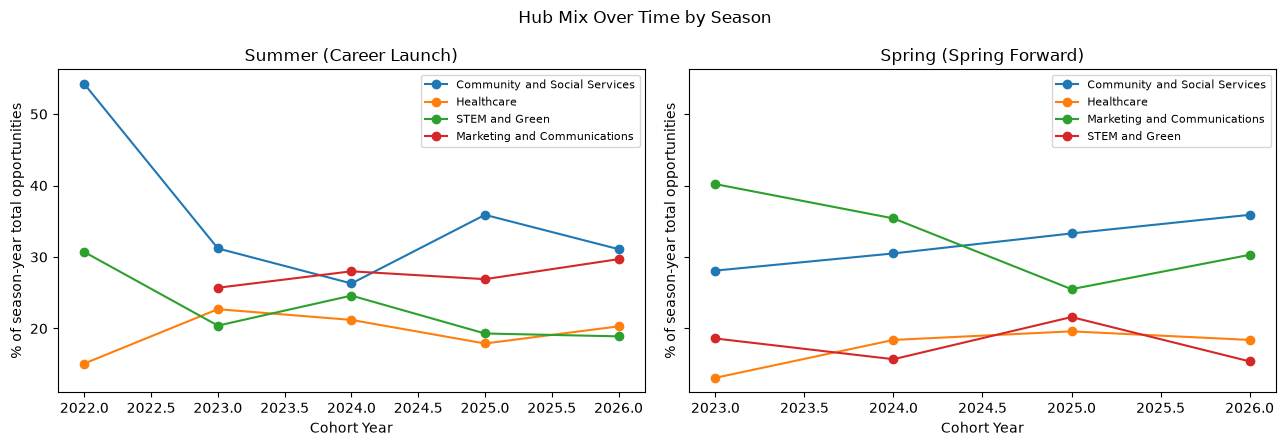


Top 8 NAICS industries by year and season (% of season-year total)
NAICS Title                          Advertising, Public Relations, and Related Services  Colleges, Universities, and Professional Schools  Computer Systems Design and Related Services  General Medical and Surgical Hospitals  Individual and Family Services  Internet Publishing and Broadcasting and Web Search Portals  Management, Scientific, and Technical Consulting Services  Outpatient Care Centers
Cohort Year Internship Season                                                                                                                                                                                                                                                                                                                                                                                    
2022        Summer (Career Launch)                                                   0.7                                        

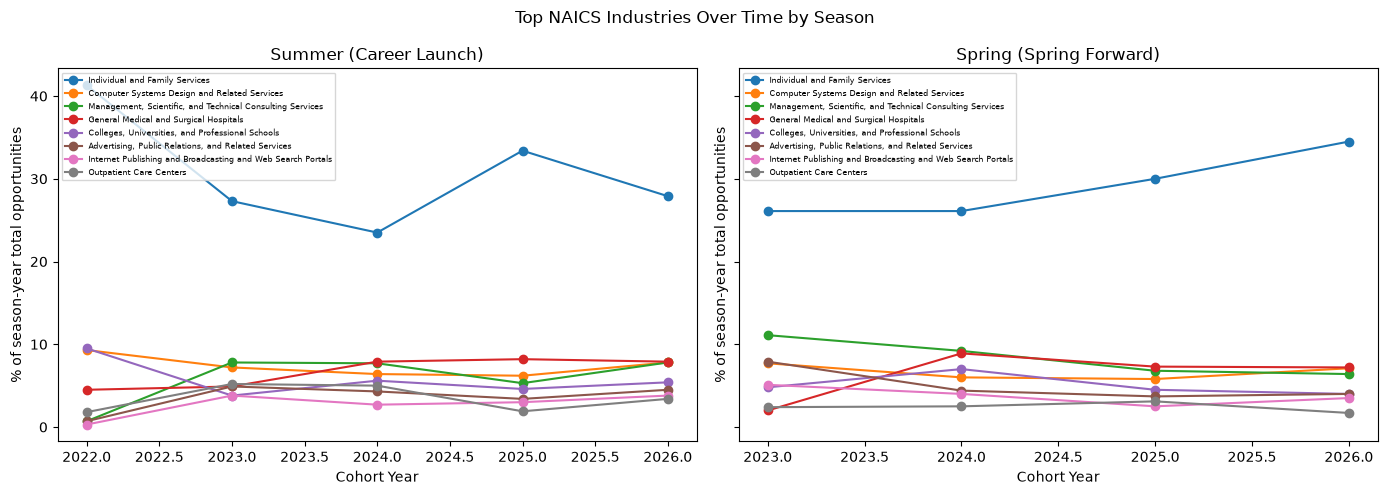


Top 8 SOC occupations by year and season (% of season-year total)
SOC Title                            Insufficient Information  Market Research Analysts and Marketing Specialists  Marketing Managers  Office and Administrative Support Workers, All Other  Receptionists and Information Clerks  Social and Human Service Assistants  Web Developers  Web and Digital Interface Designers
Cohort Year Internship Season                                                                                                                                                                                                                                                                                              
2022        Summer (Career Launch)                        9.8                                                 3.2                 2.0                                                   2.3                                   3.0                                  9.0             1.5                       

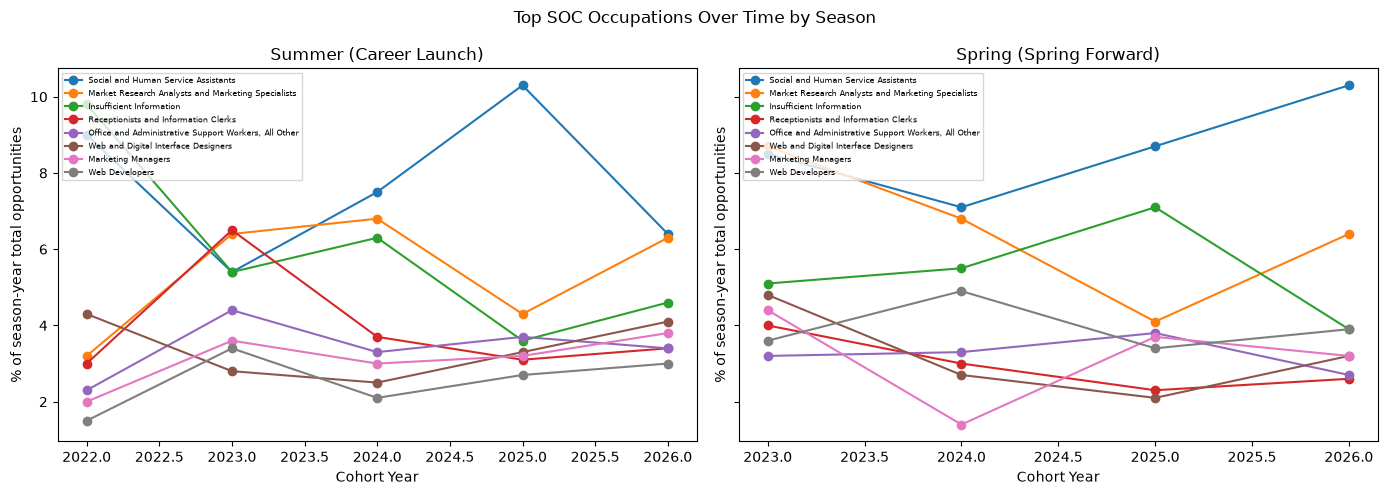



Tidy CSVs written for Power BI / further reporting:
  ../../data/timeseries_hub_by_year_season.csv
  ../../data/timeseries_naics_by_year_season.csv  (all NAICS titles, not just top 8)
  ../../data/timeseries_soc_by_year_season.csv    (all SOC titles, not just top 8)

Each has one row per (Cohort Year, Internship Season, Category) with both the raw
Count and Percent Of Season-Year Total - a Power BI line/area chart can use these
directly with Cohort Year on the x-axis, Internship Season as a slicer/legend split,
and Percent Of Season-Year Total as the value, without any further transformation.


In [10]:
# --- Time-series view: how hub / industry / occupation mix changes across
#     cohort years and internship seasons, standardized to % of total ---
#
# "Season" here is really Program Family: Career Launch = Summer cohort,
# Spring Forward = Spring cohort. Standardizing to % of that season-year's
# total opportunities matters because raw volume grew a lot 2022 -> 2026
# (we saw this in the earlier hub-by-year pivot) - looking at raw counts
# over time would just show "everything grew," which isn't the interesting
# question. % of total shows whether the MIX shifted, independent of
# overall growth.

import pandas as pd
import matplotlib.pyplot as plt

READY_PATH = "../../data/AllRoles_nioccs_ready.csv"
CODED_PATH = "../../data/AllRoles_nioccs_coded.csv"

SEASON_MAP = {"Career Launch": "Summer (Career Launch)", "Spring Forward": "Spring (Spring Forward)"}

ready = pd.read_csv(READY_PATH, encoding="utf-8-sig")
coded = pd.read_csv(CODED_PATH, encoding="utf-8-sig")

# The coded file doesn't carry Cohort Year / Program Family (only what the
# API needed), so bring those back in via the ready file.
merged = coded.merge(
    ready[["Opportunity Identifier", "Cohort Year", "Program Family"]],
    on="Opportunity Identifier",
    how="left",
)

n_unmatched = merged["Cohort Year"].isna().sum()
if n_unmatched:
    print(f"NOTE: {n_unmatched} coded rows didn't match anything in the ready file "
          f"and have no Cohort Year/Season - excluded from the time series below.")

merged = merged.dropna(subset=["Cohort Year", "Program Family"])
merged = merged[merged["API Call Error"].isna()]  # only successfully coded rows
merged["Internship Season"] = merged["Program Family"].map(SEASON_MAP)
merged["Cohort Year"] = merged["Cohort Year"].astype(int)

print(f"Rows going into the time series: {len(merged)}\n")


def pct_of_group_total(df, group_cols, value_col):
    """Returns counts AND % of each (Cohort Year, Internship Season) group's total."""
    counts = df.groupby(group_cols + [value_col]).size().rename("Count").reset_index()
    group_totals = counts.groupby(group_cols)["Count"].transform("sum")
    counts["Percent Of Season-Year Total"] = (counts["Count"] / group_totals * 100).round(1)
    return counts


# ------------------------------------------------------------------
# 1. Hub mix over time, by season
# ------------------------------------------------------------------
hub_trend = pct_of_group_total(merged, ["Cohort Year", "Internship Season"], "Program Hub Category")
hub_trend.to_csv("../../data/timeseries_hub_by_year_season.csv", index=False)

print("=" * 70)
print("Hub mix by year and season (% of that season-year's total opportunities)")
print("=" * 70)
hub_pivot = hub_trend.pivot_table(
    index=["Cohort Year", "Internship Season"], columns="Program Hub Category",
    values="Percent Of Season-Year Total", fill_value=0
)
print(hub_pivot.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, season in zip(axes, SEASON_MAP.values()):
    sub = hub_trend[hub_trend["Internship Season"] == season]
    for hub in sub["Program Hub Category"].unique():
        s = sub[sub["Program Hub Category"] == hub].sort_values("Cohort Year")
        ax.plot(s["Cohort Year"], s["Percent Of Season-Year Total"], marker="o", label=hub)
    ax.set_title(season)
    ax.set_xlabel("Cohort Year")
    ax.set_ylabel("% of season-year total opportunities")
    ax.legend(fontsize=8)
plt.suptitle("Hub Mix Over Time by Season")
plt.tight_layout()
plt.savefig("../../data/timeseries_hub_by_year_season.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 2. Industry (NAICS) mix over time, by season - top 8 NAICS titles overall
# ------------------------------------------------------------------
top_naics_titles = merged["NAICS Title"].value_counts().head(8).index.tolist()
naics_trend_all = pct_of_group_total(merged, ["Cohort Year", "Internship Season"], "NAICS Title")
naics_trend = naics_trend_all[naics_trend_all["NAICS Title"].isin(top_naics_titles)]
naics_trend_all.to_csv("../../data/timeseries_naics_by_year_season.csv", index=False)

print("\n" + "=" * 70)
print("Top 8 NAICS industries by year and season (% of season-year total)")
print("=" * 70)
naics_pivot = naics_trend.pivot_table(
    index=["Cohort Year", "Internship Season"], columns="NAICS Title",
    values="Percent Of Season-Year Total", fill_value=0
)
print(naics_pivot.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, season in zip(axes, SEASON_MAP.values()):
    sub = naics_trend[naics_trend["Internship Season"] == season]
    for title in top_naics_titles:
        s = sub[sub["NAICS Title"] == title].sort_values("Cohort Year")
        ax.plot(s["Cohort Year"], s["Percent Of Season-Year Total"], marker="o", label=title)
    ax.set_title(season)
    ax.set_xlabel("Cohort Year")
    ax.set_ylabel("% of season-year total opportunities")
    ax.legend(fontsize=6, loc="upper left")
plt.suptitle("Top NAICS Industries Over Time by Season")
plt.tight_layout()
plt.savefig("../../data/timeseries_naics_by_year_season.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 3. Occupation (SOC) mix over time, by season - top 8 SOC titles overall
# ------------------------------------------------------------------
top_soc_titles = merged["SOC Title"].value_counts().head(8).index.tolist()
soc_trend_all = pct_of_group_total(merged, ["Cohort Year", "Internship Season"], "SOC Title")
soc_trend = soc_trend_all[soc_trend_all["SOC Title"].isin(top_soc_titles)]
soc_trend_all.to_csv("../../data/timeseries_soc_by_year_season.csv", index=False)

print("\n" + "=" * 70)
print("Top 8 SOC occupations by year and season (% of season-year total)")
print("=" * 70)
soc_pivot = soc_trend.pivot_table(
    index=["Cohort Year", "Internship Season"], columns="SOC Title",
    values="Percent Of Season-Year Total", fill_value=0
)
print(soc_pivot.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, season in zip(axes, SEASON_MAP.values()):
    sub = soc_trend[soc_trend["Internship Season"] == season]
    for title in top_soc_titles:
        s = sub[sub["SOC Title"] == title].sort_values("Cohort Year")
        ax.plot(s["Cohort Year"], s["Percent Of Season-Year Total"], marker="o", label=title)
    ax.set_title(season)
    ax.set_xlabel("Cohort Year")
    ax.set_ylabel("% of season-year total opportunities")
    ax.legend(fontsize=6, loc="upper left")
plt.suptitle("Top SOC Occupations Over Time by Season")
plt.tight_layout()
plt.savefig("../../data/timeseries_soc_by_year_season.png", dpi=150)
plt.show()

print("\n\nTidy CSVs written for Power BI / further reporting:")
print("  ../../data/timeseries_hub_by_year_season.csv")
print("  ../../data/timeseries_naics_by_year_season.csv  (all NAICS titles, not just top 8)")
print("  ../../data/timeseries_soc_by_year_season.csv    (all SOC titles, not just top 8)")
print("\nEach has one row per (Cohort Year, Internship Season, Category) with both the raw")
print("Count and Percent Of Season-Year Total - a Power BI line/area chart can use these")
print("directly with Cohort Year on the x-axis, Internship Season as a slicer/legend split,")
print("and Percent Of Season-Year Total as the value, without any further transformation.")

## 2023 First Diagnostic

In [5]:
# --- Digging into the 2023 "Insufficient Information" spike ---
#
# A few hypotheses worth checking directly against the data before
# guessing:
#   1. Did 2023 postings tend to have noticeably shorter/thinner
#      descriptions than other years?
#   2. Did the "DUTIES & RESPONSIBILITIES:" header (which our duties
#      extraction relies on) actually appear less often in 2023 postings -
#      i.e. did the posting template change that year, so we fell back to
#      sending the full (possibly boilerplate-heavy) description instead
#      of the targeted duties section?
#   3. Is this concentrated in a handful of agencies, or spread evenly -
#      i.e. is this a "a few agencies post thin listings" story or a
#      "something changed platform-wide in 2023" story?
#   4. What do the actual flagged 2023 rows look like, in plain text?

import pandas as pd
import re

READY_PATH = "../../data/AllRoles_nioccs_ready.csv"
CODED_PATH = "../../data/AllRoles_nioccs_coded.csv"

DUTIES_HEADER_RE = re.compile(r"duties\s*&?\s*responsibilities\s*:?", re.I)

ready = pd.read_csv(READY_PATH, encoding="utf-8-sig")
coded = pd.read_csv(CODED_PATH, encoding="utf-8-sig")

merged = coded.merge(
    ready[["Opportunity Identifier", "Cohort Year", "Program Family", "Agency Name", "Role Description"]],
    on="Opportunity Identifier",
    how="left",
)
merged = merged.dropna(subset=["Cohort Year"])
merged = merged[merged["API Call Error"].isna()]
merged["Cohort Year"] = merged["Cohort Year"].astype(int)
merged["Description Word Count"] = merged["Role Description"].apply(
    lambda t: len(str(t).split()) if pd.notna(t) else 0
)
merged["Duties Header Found"] = merged["Role Description"].apply(
    lambda t: bool(DUTIES_HEADER_RE.search(str(t))) if pd.notna(t) else False
)

# ------------------------------------------------------------------
# 1. Insufficient-information rate by year - confirm and quantify the spike
# ------------------------------------------------------------------
print("=" * 70)
print("SOC 'Insufficient Information' rate by Cohort Year")
print("=" * 70)
by_year = merged.groupby("Cohort Year").agg(
    Total_Rows=("Opportunity Identifier", "count"),
    SOC_Insufficient_Rate_Pct=("SOC Flagged As Insufficient Information", lambda s: round(s.mean() * 100, 1)),
    NAICS_Insufficient_Rate_Pct=("NAICS Flagged As Insufficient Information", lambda s: round(s.mean() * 100, 1)),
    Avg_Description_Word_Count=("Description Word Count", lambda s: round(s.mean(), 1)),
    Pct_Rows_With_Duties_Header=("Duties Header Found", lambda s: round(s.mean() * 100, 1)),
)
print(by_year.to_string())

# ------------------------------------------------------------------
# 2. Zoom into 2023 specifically vs. all other years
# ------------------------------------------------------------------
year_2023 = merged[merged["Cohort Year"] == 2023]
other_years = merged[merged["Cohort Year"] != 2023]

print(f"\n2023 rows: {len(year_2023)}")
print(f"2023 SOC insufficient-info rate: {year_2023['SOC Flagged As Insufficient Information'].mean() * 100:.1f}%")
print(f"All other years SOC insufficient-info rate: {other_years['SOC Flagged As Insufficient Information'].mean() * 100:.1f}%")

print(f"\n2023 avg description word count: {year_2023['Description Word Count'].mean():.1f}")
print(f"Other years avg description word count: {other_years['Description Word Count'].mean():.1f}")

print(f"\n2023 % of rows where a DUTIES & RESPONSIBILITIES header was found: "
      f"{year_2023['Duties Header Found'].mean() * 100:.1f}%")
print(f"Other years % of rows where a DUTIES & RESPONSIBILITIES header was found: "
      f"{other_years['Duties Header Found'].mean() * 100:.1f}%")

# ------------------------------------------------------------------
# 3. Is it concentrated in specific agencies, or platform-wide?
# ------------------------------------------------------------------
flagged_2023 = year_2023[year_2023["SOC Flagged As Insufficient Information"]]
print(f"\n2023 rows flagged insufficient: {len(flagged_2023)}")
print("\nTop agencies among 2023 insufficient-information rows:")
print(flagged_2023["Agency Name"].value_counts().head(10).to_string())

n_agencies_2023_flagged = flagged_2023["Agency Name"].nunique()
n_agencies_2023_total = year_2023["Agency Name"].nunique()
print(f"\n{n_agencies_2023_flagged} distinct agencies among flagged 2023 rows, "
      f"out of {n_agencies_2023_total} distinct agencies in 2023 overall.")
print("(If this is a small handful of agencies driving most of the flagged rows, "
      "it's a few-bad-postings story. If it's spread across most agencies, "
      "something more systemic changed that year.)")

# ------------------------------------------------------------------
# 4. Show actual examples - title + description snippet - for manual review
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("Sample of 2023 rows flagged 'Insufficient Information' (for manual review)")
print("=" * 70)
sample = flagged_2023.sample(min(8, len(flagged_2023)), random_state=1)
for _, row in sample.iterrows():
    print(f"\nRole Name: {row['Role Name']!r}")
    print(f"Agency: {row['Agency Name']!r}")
    print(f"Duties header found: {row['Duties Header Found']}")
    print(f"Description word count: {row['Description Word Count']}")
    print(f"Description (first 300 chars): {str(row['Role Description'])[:300]!r}")

# ------------------------------------------------------------------
# 5. For comparison, show a few NON-flagged 2023 rows the same way
# ------------------------------------------------------------------
not_flagged_2023 = year_2023[~year_2023["SOC Flagged As Insufficient Information"]]
print("\n" + "=" * 70)
print("For comparison: sample of 2023 rows NOT flagged (successfully coded)")
print("=" * 70)
sample2 = not_flagged_2023.sample(min(5, len(not_flagged_2023)), random_state=1)
for _, row in sample2.iterrows():
    print(f"\nRole Name: {row['Role Name']!r}")
    print(f"Duties header found: {row['Duties Header Found']}")
    print(f"Description word count: {row['Description Word Count']}")
    print(f"SOC Title: {row['SOC Title']!r}")

SOC 'Insufficient Information' rate by Cohort Year
             Total_Rows  SOC_Insufficient_Rate_Pct  NAICS_Insufficient_Rate_Pct  Avg_Description_Word_Count  Pct_Rows_With_Duties_Header
Cohort Year                                                                                                                             
2022                603                        9.8                          1.3                       223.9                          0.0
2023               1416                       15.7                          1.3                       306.3                          3.5
2024               1580                        6.0                          0.6                       342.4                         64.4
2025               1673                        5.1                          0.9                       348.8                         66.6
2026               1853                        4.3                          0.6                       404.2                    

In [7]:
# --- NIOCCS NAICS/SOC auto-classification - call the API on AllRoles_nioccs_ready.csv ---
#
# NOTE: I can't hit wwwn.cdc.gov from my own sandbox to test this end-to-end,
# so treat the first TEST_MODE run below as the real verification step -
# check the raw JSON it prints before trusting the parsed columns or moving
# to the full batch. Field names in `parse_nioccs_response` are my best read
# of the spec you gave me; adjust them once you see a real response.

import pandas as pd
import requests
import time
import json
import os

IN_PATH = "../../data/AllRoles_nioccs_ready.csv"
CHECKPOINT_PATH = "../../data/AllRoles_nioccs_coded.csv"

NIOCCS_BASE_URL = "https://wwwn.cdc.gov/nioccs/IOCode"
REQUEST_PARAMS_STATIC = {"c": 2, "v": 18, "u": 1, "n": 1}

import re

# Cap on the occupation text sent to the API. Section extraction (below)
# does the real trimming work now; this is a safety ceiling. Raised from
# 1200 - 2022/2023-era descriptions run long (250-1000+ words) and the
# real content sometimes sits well past the old cutoff.
MAX_DESCRIPTION_CHARS = 2000

# Postings use several DIFFERENT template formats depending on the era:
#   - 2024+: "DUTIES & RESPONSIBILITIES:" header (clean, easy to anchor on)
#   - 2022-2023: no consistent header - instead, free-form paragraphs, an
#     intake-form Q&A style ("Please provide a description of this
#     position, including job responsibilities and tasks:"), or headers
#     like "Position Overview:" / "Projects & Deliverables may include:"
#
# Rather than one fixed header, try a PRIORITIZED list of anchor phrases,
# in order, and stop at whichever known "next section" phrase comes after
# whichever anchor matched. This handles the era mix instead of assuming
# everything looks like the newest template.
DUTIES_ANCHOR_PATTERNS = [
    re.compile(r"duties\s*&?\s*responsibilities\s*:?", re.I),
    re.compile(r"job responsibilities and tasks\s*:?", re.I),
    re.compile(r"projects?\s*&?\s*deliverables?\s*(may include)?\s*:?", re.I),
    re.compile(r"position overview\s*:?", re.I),
    re.compile(r"responsibilities\s*:?", re.I),
]
NEXT_SECTION_HEADER_RE = re.compile(
    r"(intern will learn|what do you predict|qualifications|work schedule|"
    r"location\s*:|^\s*\d+\.\s|compensation)", re.I | re.M
)

# If the text right after an anchor is this short before hitting the next
# section marker, treat it as effectively blank - i.e. an unfilled intake
# form question rather than real content (the Zone126 case).
MIN_CHARS_AFTER_ANCHOR_TO_COUNT_AS_CONTENT = 25

# Boilerplate opening patterns to skip past when NO duties anchor is found
# at all, so we don't just send raw "About [Agency]..." mission-statement
# text as the occupation description.
ORG_BOILERPLATE_OPENING_RE = re.compile(
    r"^\s*(about\s+[\w\s]+:|who we are\s*:|recently rated|is a multifaith|"
    r"is a nonprofit|is a non-profit)", re.I
)


def extract_duties_text(description: str) -> tuple:
    """
    Returns (extracted_text, anchor_found, flagged_as_blank_intake_form).

    Tries each anchor pattern in DUTIES_ANCHOR_PATTERNS in order and uses
    the first one found, stopping at the next known section marker. If an
    anchor is found but there's almost nothing before the next section
    marker, flags it as a likely-blank intake form rather than pretending
    it has content. If no anchor is found at all, falls back to the full
    description (still capped by MAX_DESCRIPTION_CHARS downstream).
    """
    if pd.isna(description):
        return "", False, True
    text = str(description)

    for pattern in DUTIES_ANCHOR_PATTERNS:
        match = pattern.search(text)
        if not match:
            continue
        after_anchor = text[match.end():]
        next_marker = NEXT_SECTION_HEADER_RE.search(after_anchor)
        extracted = after_anchor[: next_marker.start()] if next_marker else after_anchor
        extracted = extracted.strip()

        if len(extracted) < MIN_CHARS_AFTER_ANCHOR_TO_COUNT_AS_CONTENT:
            # Anchor found, but nothing real follows it before the next
            # question/section - this is the Zone126 pattern: an
            # unanswered intake-form prompt, not real duties content.
            return extracted, True, True

        return extracted, True, False

    # No anchor matched at all - fall back to the full description, but
    # skip past an org-mission-statement opening paragraph if there is one,
    # so we don't waste the character budget on "About [Agency]..." text.
    boilerplate_match = ORG_BOILERPLATE_OPENING_RE.search(text)
    if boilerplate_match:
        first_break = text.find(".", boilerplate_match.end())
        if first_break != -1 and first_break < len(text) - 1:
            text = text[first_break + 1:].strip()

    return text, False, False

# TEST_MODE = True runs on just the first TEST_SAMPLE_SIZE rows and prints
# the raw response for each, so you can sanity-check field names before
# committing to the full batch. Flip to False (and re-run the cell) once
# you've confirmed the parsing looks right.
TEST_MODE = True
TEST_SAMPLE_SIZE = 10

# Be a polite, unauthenticated guest on a free public CDC endpoint.
SECONDS_BETWEEN_REQUESTS = 0.5
MAX_RETRIES_PER_ROW = 3

# Sentinel codes per the NIOCCS spec - these mean "insufficient information
# to code," not a real match.
NAICS_INSUFFICIENT_INFO_CODE = "009990"
SOC_INSUFFICIENT_INFO_CODE = "00-9900"


def build_occupation_text(role_name: str, role_description: str) -> tuple:
    """Returns (occupation_text, duties_anchor_found, flagged_as_blank_intake_form)."""
    role_name = "" if pd.isna(role_name) else str(role_name).strip()
    duties_text, anchor_found, blank_intake_form = extract_duties_text(role_description)
    combined = f"{role_name}. {duties_text}"
    return combined[:MAX_DESCRIPTION_CHARS], anchor_found, blank_intake_form


def call_nioccs(industry_text: str, occupation_text: str) -> dict:
    """
    Calls the NIOCCS API for a single row. Returns a dict with:
      - 'raw_response': the parsed JSON (or None if the call failed)
      - 'http_status': status code (or None)
      - 'error': error message if something went wrong, else None
    Retries transient failures a few times before giving up on the row.
    """
    params = {
        **REQUEST_PARAMS_STATIC,
        "i": industry_text,
        "o": occupation_text,
    }

    last_error = None
    for attempt in range(1, MAX_RETRIES_PER_ROW + 1):
        try:
            resp = requests.get(NIOCCS_BASE_URL, params=params, timeout=20)
            if resp.status_code == 200:
                try:
                    return {"raw_response": resp.json(), "http_status": 200, "error": None}
                except json.JSONDecodeError:
                    last_error = f"Non-JSON response (status 200): {resp.text[:200]}"
            else:
                last_error = f"HTTP {resp.status_code}: {resp.text[:200]}"
        except requests.exceptions.RequestException as e:
            last_error = f"Request exception: {e}"

        if attempt < MAX_RETRIES_PER_ROW:
            time.sleep(1.5 * attempt)  # simple backoff before retrying

    return {"raw_response": None, "http_status": None, "error": last_error}


def parse_nioccs_response(raw) -> dict:
    """
    Extracts NAICS/SOC codes from the real NIOCCS response shape (confirmed
    from a test run):

        {
          "Industry": [{"NAICSCode": ..., "NAICSTitle": ..., "NAICSProbability": ...}],
          "Occupation": [{"SOCCode": ..., "SOCTitle": ..., "SOCProbability": ...}],
          "UnexpectedCodeCombination": "Y" or "N"
        }

    Takes the first entry in each list (n=1 in the request params means we
    only asked for the top match anyway).
    """
    empty = {
        "naics_code": None, "naics_title": None, "naics_probability": None,
        "soc_code": None, "soc_title": None, "soc_probability": None,
        "naics_insufficient_info": None, "soc_insufficient_info": None,
        "implausible_pairing_flag": None,
    }
    if not isinstance(raw, dict):
        return empty

    industry = raw.get("Industry") or []
    occupation = raw.get("Occupation") or []
    industry_rec = industry[0] if industry else {}
    occupation_rec = occupation[0] if occupation else {}

    naics_code = industry_rec.get("NAICSCode")
    soc_code = occupation_rec.get("SOCCode")

    return {
        "naics_code": naics_code,
        "naics_title": industry_rec.get("NAICSTitle"),
        "naics_probability": industry_rec.get("NAICSProbability"),
        "soc_code": soc_code,
        "soc_title": occupation_rec.get("SOCTitle"),
        "soc_probability": occupation_rec.get("SOCProbability"),
        "naics_insufficient_info": (naics_code == NAICS_INSUFFICIENT_INFO_CODE) if naics_code else None,
        "soc_insufficient_info": (soc_code == SOC_INSUFFICIENT_INFO_CODE) if soc_code else None,
        "implausible_pairing_flag": raw.get("UnexpectedCodeCombination") == "Y",
    }


def load_already_coded():
    """Resume support: skip rows we've already successfully coded."""
    if os.path.exists(CHECKPOINT_PATH):
        done = pd.read_csv(CHECKPOINT_PATH)
        return done, set(done["Opportunity Identifier"])
    return pd.DataFrame(), set()


def run():
    df = pd.read_csv(IN_PATH, encoding="utf-8-sig")

    if TEST_MODE:
        df = df.head(TEST_SAMPLE_SIZE)
        print(f"TEST MODE: running on {len(df)} rows only. Set TEST_MODE = False for the full batch.\n")

    done_df, done_ids = load_already_coded()
    if not TEST_MODE and done_ids:
        print(f"Resuming: {len(done_ids)} rows already coded in a previous run, skipping those.")
        df = df[~df["Opportunity Identifier"].isin(done_ids)]

    results = []
    total = len(df)
    for i, (_, row) in enumerate(df.iterrows(), start=1):
        opportunity_id = row["Opportunity Identifier"]
        role_name = row["Role Name"]
        role_description = row["Role Description"]
        industry_text = row["Program Hub Category"]  # STEM and Green included, no special-casing

        occupation_text, duties_anchor_found, blank_intake_form = build_occupation_text(role_name, role_description)

        if blank_intake_form:
            # Genuinely unfilled intake-form template (the Zone126 pattern) -
            # there's nothing real to code, so don't spend an API call on it.
            # Recorded with its own flag rather than a generic API error, so
            # it's easy to separate from actual call failures later.
            result_row = {
                "Opportunity Identifier": opportunity_id,
                "Role Name": role_name,
                "Program Hub Category": industry_text,
                "NAICS Code": None, "NAICS Title": None, "NAICS Match Probability": None,
                "SOC Code": None, "SOC Title": None, "SOC Match Probability": None,
                "NAICS Flagged As Insufficient Information": None,
                "SOC Flagged As Insufficient Information": None,
                "Flagged As Implausible NAICS/SOC Pairing": None,
                "Duties Anchor Found In Description": duties_anchor_found,
                "Flagged As Blank Intake Form": True,
                "API Call Error": "Skipped - description is an unfilled intake-form template",
            }
            results.append(result_row)
            if TEST_MODE:
                print(f"--- Row {i}/{total}: {role_name!r} ---")
                print("SKIPPED - flagged as a blank intake-form template, no API call made.")
                print()
            continue

        api_result = call_nioccs(industry_text, occupation_text)
        parsed = parse_nioccs_response(api_result["raw_response"])

        result_row = {
            "Opportunity Identifier": opportunity_id,
            "Role Name": role_name,
            "Program Hub Category": industry_text,
            "NAICS Code": parsed["naics_code"],
            "NAICS Title": parsed["naics_title"],
            "NAICS Match Probability": parsed["naics_probability"],
            "SOC Code": parsed["soc_code"],
            "SOC Title": parsed["soc_title"],
            "SOC Match Probability": parsed["soc_probability"],
            "NAICS Flagged As Insufficient Information": parsed["naics_insufficient_info"],
            "SOC Flagged As Insufficient Information": parsed["soc_insufficient_info"],
            "Flagged As Implausible NAICS/SOC Pairing": parsed["implausible_pairing_flag"],
            "Duties Anchor Found In Description": duties_anchor_found,
            "Flagged As Blank Intake Form": False,
            "API Call Error": api_result["error"],
        }
        results.append(result_row)

        if TEST_MODE:
            print(f"--- Row {i}/{total}: {role_name!r} ---")
            print("Raw response:", json.dumps(api_result["raw_response"], indent=2)[:1000])
            print("Parsed:", {k: v for k, v in result_row.items() if k not in ("Opportunity Identifier", "Role Name")})
            print()
        elif i % 25 == 0:
            print(f"...{i}/{total} rows called")

        time.sleep(SECONDS_BETWEEN_REQUESTS)

        # Checkpoint every 100 rows in full-batch mode, so a crash mid-run
        # doesn't cost you the whole batch.
        if not TEST_MODE and i % 100 == 0:
            combined = pd.concat([done_df, pd.DataFrame(results)], ignore_index=True)
            combined.to_csv(CHECKPOINT_PATH, index=False)
            print(f"Checkpoint saved: {len(combined)} rows coded so far.")

    results_df = pd.DataFrame(results)

    if not TEST_MODE:
        combined = pd.concat([done_df, results_df], ignore_index=True)
        combined.to_csv(CHECKPOINT_PATH, index=False)
        print(f"\nDone. {len(combined)} total rows coded, written to {CHECKPOINT_PATH}")
        n_errors = combined["API Call Error"].notna().sum()
        if n_errors:
            print(f"{n_errors} rows had a call error and should be re-run separately - "
                  f"they were still saved to the checkpoint file with the error message.")
    else:
        print(f"\nTest run complete on {len(results_df)} rows. Nothing written to disk yet - "
              f"review the raw responses above, fix parse_nioccs_response if the keys don't "
              f"match, then set TEST_MODE = False and re-run this cell for the full batch.")

    return results_df


results_df = run()
results_df

TEST MODE: running on 10 rows only. Set TEST_MODE = False for the full batch.

--- Row 1/10: 'Dental Assistant - Open Bright Pediatric Dentistry' ---
Raw response: {
  "Industry": [
    {
      "NAICSCode": "621210",
      "NAICSTitle": "Offices of Dentists",
      "NAICSProbability": 0.5338548,
      "CensusIndustryCode": "7980",
      "CensusIndustryTitle": "Offices of Dentists"
    }
  ],
  "Occupation": [
    {
      "SOCCode": "31-1131",
      "SOCTitle": "Nursing Assistants",
      "SOCProbability": 0.968238235,
      "CensusOccupationCode": "3603",
      "CensusOccupationTitle": "Nursing Assistants"
    }
  ],
  "UnexpectedCodeCombination": "N",
  "Scheme": "NAICS 2017 and SOC 2018, Census Industry and Occupation 2018"
}
Parsed: {'Program Hub Category': 'Healthcare', 'NAICS Code': '621210', 'NAICS Title': 'Offices of Dentists', 'NAICS Match Probability': 0.5338548, 'SOC Code': '31-1131', 'SOC Title': 'Nursing Assistants', 'SOC Match Probability': 0.968238235, 'NAICS Flagged As I

,Opportunity Identifier,Role Name,Program Hub Category,NAICS Code,NAICS Title,NAICS Match Probability,SOC Code,SOC Title,SOC Match Probability,NAICS Flagged As Insufficient Information,SOC Flagged As Insufficient Information,Flagged As Implausible NAICS/SOC Pairing,Duties Anchor Found In Description,Flagged As Blank Intake Form,API Call Error
0,395bf964-a1f1-455f-9e41-08dd7b582abd,Dental Assistant - Open Bright Pediatric Denti...,Healthcare,621210,Offices of Dentists,0.533855,31-1131,Nursing Assistants,0.968238,False,False,False,True,False,None
1,23174e7a-34b2-4373-9e42-08dd7b582abd,Dental receptionist - Open Bright Pediatric De...,Healthcare,622310,Specialty (Except Psychiatric and Substance Ab...,0.709339,43-4171,Receptionists and Information Clerks,0.999266,False,False,False,True,False,None
2,e303552d-c68a-4108-9c75-08dd7c328786,Finance/Accounting Intern – PEN America,Community and Social Services,6241,Individual and Family Services,0.955280,43-3031,"Bookkeeping, Accounting, and Auditing Clerks",0.951212,False,False,False,True,False,None
3,456bc9db-15c3-4d6f-e196-08dd81aa123b,Software Engineer Intern - Icahn School of Med...,Healthcare,54151,Computer Systems Design and Related Services,0.959816,15-1252,Software Developers,0.985082,False,False,False,True,False,None
4,aa75f149-6cb8-40e8-e197-08dd81aa123b,Website Intern - Icahn School of Medicine at M...,Healthcare,622110,General Medical and Surgical Hospitals,0.999998,11-9111,Medical and Health Services Managers,0.382733,False,False,False,True,False,None
5,cffbac57-aab7-4ef7-e198-08dd81aa123b,Digital Marketing Intern - Mount Sinai Health ...,Healthcare,33911,Medical Equipment and Supplies Manufacturing,0.685711,11-2021,Marketing Managers,0.548664,False,False,False,True,False,None
6,87e69a26-73af-403e-9ce2-08dd7c328786,Office Assistant - Cobble Hill Health Center,Healthcare,5241,Insurance Carriers,0.516247,43-4171,Receptionists and Information Clerks,0.666312,False,False,False,True,False,None
7,a34fabed-ccca-4cb2-9ce3-08dd7c328786,Training & Technical Assistance Partnerships I...,Community and Social Services,6241,Individual and Family Services,0.999764,21-1093,Social and Human Service Assistants,0.999991,False,False,False,True,False,None
8,50b492c2-8ae5-4b17-e182-08dd81aa123b,Lectec - Graphic Designer / Content Creator In...,STEM and Green,54151,Computer Systems Design and Related Services,0.969592,15-1255,Web and Digital Interface Designers,0.999998,False,False,False,True,False,None
9,1cd698ee-e79f-4be1-e17f-08dd81aa123b,Lectec - Content Producer / Videographer Intern,STEM and Green,5121,Motion Picture and Video Industries,0.999926,27-4031,"Camera Operators, Television, Video, and Film",0.999551,False,False,False,True,False,None


In [9]:
# --- Re-run NIOCCS classification for 2023 only, then merge back into
#     AllRoles_nioccs_coded.csv ---
#
# This assumes the functions from the main API-call cell (call_nioccs,
# parse_nioccs_response, build_occupation_text, extract_duties_text) are
# already defined earlier in this notebook - it reuses them as-is rather
# than redefining them, so make sure that cell has been run first (with
# the broadened multi-anchor extraction fix already in place).
#
# Steps:
#   1. Load the ready file, filter to Cohort Year == 2023 only.
#   2. Re-run the (now-fixed) extraction + API call on just those rows.
#   3. Back up the existing coded file, then replace ONLY the 2023 rows
#      in it with the new results - 2022/2024/2025/2026 rows are left
#      completely untouched.

import pandas as pd
import time
import json
import os
import shutil

READY_PATH = "../../data/AllRoles_nioccs_ready.csv"
MAIN_CODED_PATH = "../../data/AllRoles_nioccs_coded.csv"
RERUN_2023_CHECKPOINT_PATH = "../../data/AllRoles_nioccs_coded_2023_rerun.csv"
BACKUP_PATH = "../../data/AllRoles_nioccs_coded_BACKUP_before_2023_fix.csv"

TARGET_YEAR = 2023

# Same test-first safety pattern as the main API cell - confirm on a small
# sample before committing to all ~1,400 2023 rows.
TEST_MODE = False
TEST_SAMPLE_SIZE = 10

SECONDS_BETWEEN_REQUESTS = 0.5


def load_already_rerun():
    if os.path.exists(RERUN_2023_CHECKPOINT_PATH):
        done = pd.read_csv(RERUN_2023_CHECKPOINT_PATH)
        return done, set(done["Opportunity Identifier"])
    return pd.DataFrame(), set()


def run_2023_rerun():
    ready = pd.read_csv(READY_PATH, encoding="utf-8-sig")
    year_2023 = ready[ready["Cohort Year"] == TARGET_YEAR].copy()
    print(f"2023 rows to re-code: {len(year_2023)}")

    if TEST_MODE:
        year_2023 = year_2023.head(TEST_SAMPLE_SIZE)
        print(f"TEST MODE: running on {len(year_2023)} rows only. "
              f"Set TEST_MODE = False for the full 2023 batch.\n")

    done_df, done_ids = load_already_rerun()
    if not TEST_MODE and done_ids:
        print(f"Resuming: {len(done_ids)} 2023 rows already re-coded, skipping those.")
        year_2023 = year_2023[~year_2023["Opportunity Identifier"].isin(done_ids)]

    results = []
    total = len(year_2023)
    for i, (_, row) in enumerate(year_2023.iterrows(), start=1):
        opportunity_id = row["Opportunity Identifier"]
        role_name = row["Role Name"]
        role_description = row["Role Description"]
        industry_text = row["Program Hub Category"]

        occupation_text, duties_anchor_found, blank_intake_form = build_occupation_text(
            role_name, role_description
        )

        if blank_intake_form:
            result_row = {
                "Opportunity Identifier": opportunity_id,
                "Role Name": role_name,
                "Program Hub Category": industry_text,
                "NAICS Code": None, "NAICS Title": None, "NAICS Match Probability": None,
                "SOC Code": None, "SOC Title": None, "SOC Match Probability": None,
                "NAICS Flagged As Insufficient Information": None,
                "SOC Flagged As Insufficient Information": None,
                "Flagged As Implausible NAICS/SOC Pairing": None,
                "Duties Anchor Found In Description": duties_anchor_found,
                "Flagged As Blank Intake Form": True,
                "API Call Error": "Skipped - description is an unfilled intake-form template",
            }
            results.append(result_row)
            if TEST_MODE:
                print(f"--- Row {i}/{total}: {role_name!r} --- SKIPPED (blank intake form)\n")
            continue

        api_result = call_nioccs(industry_text, occupation_text)
        parsed = parse_nioccs_response(api_result["raw_response"])

        result_row = {
            "Opportunity Identifier": opportunity_id,
            "Role Name": role_name,
            "Program Hub Category": industry_text,
            "NAICS Code": parsed["naics_code"],
            "NAICS Title": parsed["naics_title"],
            "NAICS Match Probability": parsed["naics_probability"],
            "SOC Code": parsed["soc_code"],
            "SOC Title": parsed["soc_title"],
            "SOC Match Probability": parsed["soc_probability"],
            "NAICS Flagged As Insufficient Information": parsed["naics_insufficient_info"],
            "SOC Flagged As Insufficient Information": parsed["soc_insufficient_info"],
            "Flagged As Implausible NAICS/SOC Pairing": parsed["implausible_pairing_flag"],
            "Duties Anchor Found In Description": duties_anchor_found,
            "Flagged As Blank Intake Form": False,
            "API Call Error": api_result["error"],
        }
        results.append(result_row)

        if TEST_MODE:
            print(f"--- Row {i}/{total}: {role_name!r} ---")
            print("Occupation text sent:", occupation_text[:200])
            print("Parsed:", {k: v for k, v in result_row.items() if k not in ("Opportunity Identifier", "Role Name")})
            print()
        elif i % 100 == 0:
            print(f"...{i}/{total} 2023 rows re-coded")

        time.sleep(SECONDS_BETWEEN_REQUESTS)

        if not TEST_MODE and i % 100 == 0:
            combined = pd.concat([done_df, pd.DataFrame(results)], ignore_index=True)
            combined.to_csv(RERUN_2023_CHECKPOINT_PATH, index=False)
            print(f"Checkpoint saved: {len(combined)} 2023 rows re-coded so far.")

    results_df = pd.DataFrame(results)

    if TEST_MODE:
        print(f"\nTest run complete on {len(results_df)} 2023 rows. Nothing written to disk yet - "
              f"review the output above, then set TEST_MODE = False and re-run this cell for "
              f"the full 2023 batch.")
        return results_df

    combined = pd.concat([done_df, results_df], ignore_index=True)
    combined.to_csv(RERUN_2023_CHECKPOINT_PATH, index=False)
    n_errors = combined["API Call Error"].notna().sum()
    print(f"\n2023 re-run complete: {len(combined)} rows written to {RERUN_2023_CHECKPOINT_PATH}")
    if n_errors:
        print(f"{n_errors} rows had a call error or were skipped as blank intake forms.")

    return combined


def merge_2023_fix_into_main_coded_file(rerun_2023_df: pd.DataFrame):
    """
    Replaces the 2023 rows in AllRoles_nioccs_coded.csv with the freshly
    re-coded ones, leaving every other year's rows untouched. Backs up the
    original file first.
    """
    if not os.path.exists(MAIN_CODED_PATH):
        raise FileNotFoundError(
            f"{MAIN_CODED_PATH} doesn't exist yet - nothing to merge into. "
            f"Run the full original batch first."
        )

    shutil.copy(MAIN_CODED_PATH, BACKUP_PATH)
    print(f"Backed up existing coded file to {BACKUP_PATH}")

    main_coded = pd.read_csv(MAIN_CODED_PATH, encoding="utf-8-sig")
    n_before = len(main_coded)

    ids_being_replaced = set(rerun_2023_df["Opportunity Identifier"])
    kept_rows = main_coded[~main_coded["Opportunity Identifier"].isin(ids_being_replaced)]

    print(f"Rows in existing coded file: {n_before}")
    print(f"Rows being replaced (old 2023 results): {n_before - len(kept_rows)}")
    print(f"Rows from the 2023 re-run being inserted: {len(rerun_2023_df)}")

    updated = pd.concat([kept_rows, rerun_2023_df], ignore_index=True)
    updated.to_csv(MAIN_CODED_PATH, index=False)

    print(f"\nUpdated {MAIN_CODED_PATH}: {len(updated)} total rows "
          f"(was {n_before} before the merge).")
    print("2022, 2024, 2025, and 2026 rows were not touched.")

    return updated


# --- Run the 2023 re-classification ---
rerun_2023_results = run_2023_rerun()

# --- Only merge back into the main file once you're out of TEST_MODE and
#     have the full 2023 batch re-coded. Uncomment the line below once
#     TEST_MODE = False has been run and completed. ---
updated_coded = merge_2023_fix_into_main_coded_file(rerun_2023_results)

2023 rows to re-code: 1416
...100/1416 2023 rows re-coded
Checkpoint saved: 100 2023 rows re-coded so far.
...200/1416 2023 rows re-coded
Checkpoint saved: 200 2023 rows re-coded so far.
...300/1416 2023 rows re-coded
Checkpoint saved: 300 2023 rows re-coded so far.
...400/1416 2023 rows re-coded
Checkpoint saved: 400 2023 rows re-coded so far.
...500/1416 2023 rows re-coded
Checkpoint saved: 500 2023 rows re-coded so far.
...600/1416 2023 rows re-coded
Checkpoint saved: 600 2023 rows re-coded so far.
...700/1416 2023 rows re-coded
Checkpoint saved: 700 2023 rows re-coded so far.
...800/1416 2023 rows re-coded
Checkpoint saved: 800 2023 rows re-coded so far.
...900/1416 2023 rows re-coded
Checkpoint saved: 900 2023 rows re-coded so far.
...1000/1416 2023 rows re-coded
Checkpoint saved: 1000 2023 rows re-coded so far.
...1100/1416 2023 rows re-coded
Checkpoint saved: 1100 2023 rows re-coded so far.
...1200/1416 2023 rows re-coded
Checkpoint saved: 1200 2023 rows re-coded so far.
...1300